<a href="https://colab.research.google.com/github/Nancyrana1/Deep-Learning/blob/main/perceptron_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from sklearn.datasets import make_classification
import numpy as np

X,y = make_classification(n_samples=100, n_features=2, n_informative = 1, n_redundant = 0,
                          n_classes = 2, n_clusters_per_class = 1, random_state = 41, hypercube = False, class_sep=10)


In [50]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

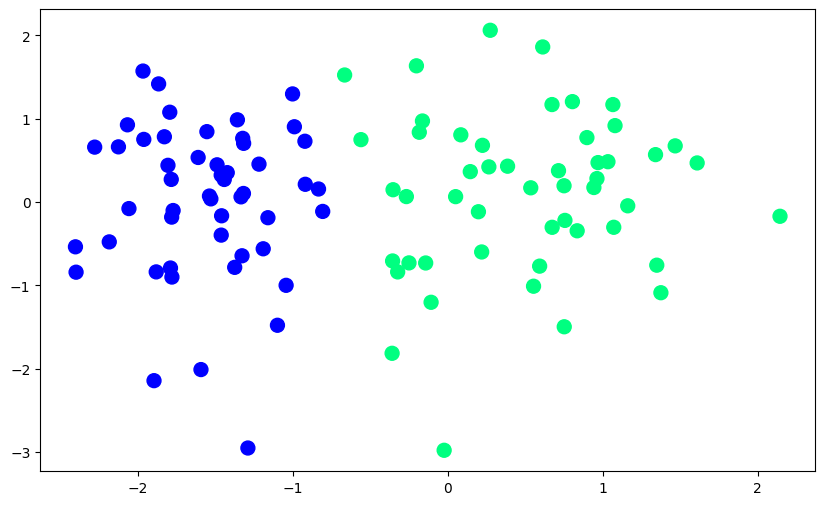

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap = 'winter', s=100)

In [52]:
from sklearn.linear_model import Perceptron

In [53]:
def perceptron(X,y):
  X = np.insert(X, 0, 1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100)    # which student to select
    y_hat = step(np.dot(X[j],weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]

  return weights[0],weights[1:]

In [54]:
def step(z):
  return 1 if z>0 else 0

In [55]:
intercept_,coef_ =perceptron(X,y)

print(intercept_)
print(coef_)

1.0
[1.3845376  0.23779665]


In [56]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [57]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

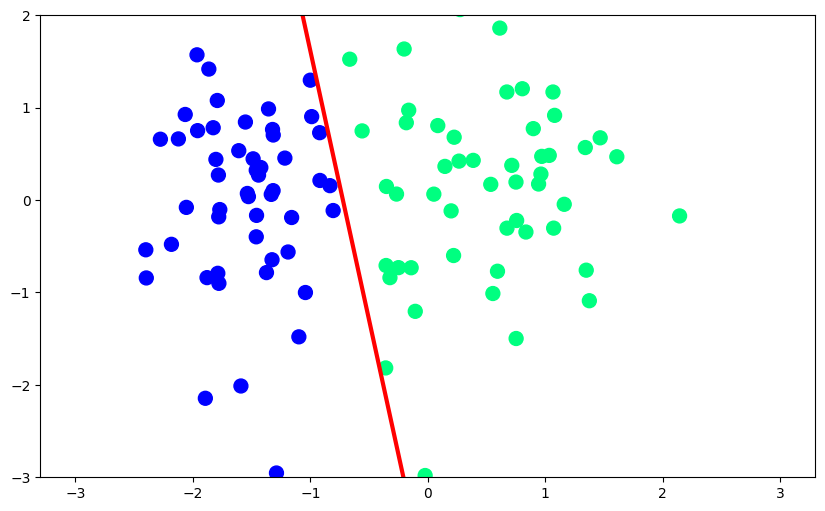

In [58]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth=3)

plt.scatter(X[:,0],X[:,1],c=y,cmap = 'winter', s=100)

plt.ylim(-3,2)

### ANIMATION OF LINE

In [59]:
pip install ipympl

In [60]:
def perceptron(X, y):

    m = []
    b = []

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

        m.append(-(weights[1] / weights[2]))
        b.append(-(weights[0] / weights[2]))

    return m, b


m, b = perceptron(X, y)

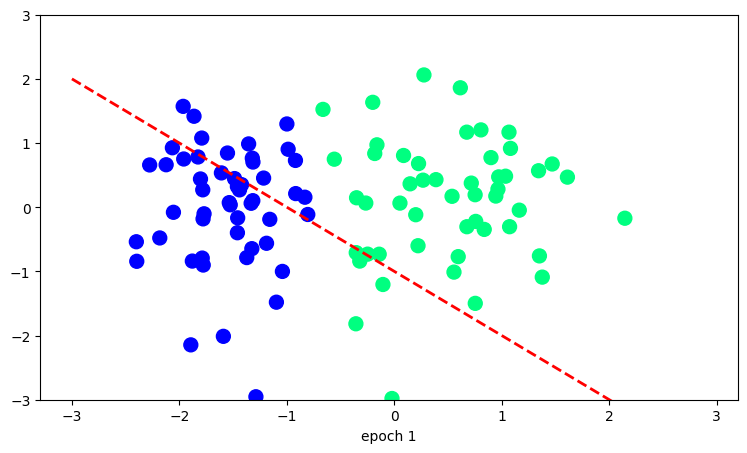

In [63]:
# %matplotlib notebook

from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(9, 5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i * m[0] + b[0]

ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, x_i * m[0] + b[0], 'r--', linewidth=2)
plt.ylim(-3, 3)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i * m[i] + b[i])
    ax.set_xlabel(label)
    return line, ax

anim = FuncAnimation(
    fig,
    update,
    frames=len(m),
    interval=100
)

In [62]:
def step(z):
    return 1 if z >= 0 else 0